### **Cell 1: Environment Diagnostics**

**Purpose:** Verify that the core compute frameworks and accelerators are accessible before running any file operations.

**Expected Successful Output:** Framework versions and your GPU status print cleanly with a success notice.


In [1]:
import os
import cv2
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

%matplotlib inline

print("=== [CELL 1] Checking Environment Stability ===")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Device Name: {torch.cuda.get_device_name(0)}")
print(f"OpenCV Version: {cv2.__version__}")
print("Status: SUCCESS - Environment is verified.")


=== [CELL 1] Checking Environment Stability ===
PyTorch Version: 2.5.1+cu121
CUDA Available: True
CUDA Device Name: Quadro T2000
OpenCV Version: 5.0.0
Status: SUCCESS - Environment is verified.


### **Cell 2: Target Path Selection**

**Purpose:** Ensure the notebook can automatically resolve the relative workspace paths without throwing hard path-not-found errors.

**Expected Successful Output:** The script confirms it successfully hit the target root directory on disk and displays the absolute path.


In [2]:
print("=== [CELL 2] Resolving Dataset Directory Paths ===")

# Check local container paths vs root project execution structures
data_dir = "../../data/raw/mvtec_ad"
if not os.path.exists(data_dir):
    data_dir = "data/raw/mvtec_ad"

print(f"Attempting to target directory: {data_dir}")
print(f"Absolute resolved path: {os.path.abspath(data_dir)}")

if os.path.exists(data_dir):
    print(f"Status: SUCCESS - Found data directory containing {len(os.listdir(data_dir))} items/categories.")
else:
    print("Status: CRITICAL FAILURE - Directory does not exist on disk.")
    print("Action Required: Please run 'just download-data' or manually stage MVTec AD.")


=== [CELL 2] Resolving Dataset Directory Paths ===
Attempting to target directory: ../../data/raw/mvtec_ad
Absolute resolved path: /home/benni/Documents/antigravity_workspace/industrial-component-anomaly-detection/data/raw/mvtec_ad
Status: SUCCESS - Found data directory containing 17 items/categories.


### **Cell 3: Accelerated Short-Circuit File Search**

**Purpose:** Locate the very first available structural image file and stop instantly, mitigating the memory/time trap of reading the whole tree.

**Expected Successful Output:** Execution ends instantly and displays the direct path to the target test image it locked onto.


In [3]:
print("=== [CELL 3] Initiating Fast File Traversal ===")

sample_path = None

for root, dirs, files in os.walk(data_dir):
    # Performance Optimization: Prevent traversal into hidden directories (.git, .cache, etc.)
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    
    for file in files:
        if file.lower().endswith((".png", ".bmp", ".jpg", ".jpeg")):
            sample_path = os.path.join(root, file)
            break  # Break out of the local file array scan
            
    if sample_path:
        break  # Short-circuit the deep folder walk entirely

if sample_path:
    print(f"Status: SUCCESS - Located valid file instance.")
    print(f"Relative File Path: {sample_path}")
    print(f"Filename: {os.path.basename(sample_path)}")
else:
    print("Status: FAILURE - No valid images found matching standard formats.")

=== [CELL 3] Initiating Fast File Traversal ===
Status: SUCCESS - Located valid file instance.
Relative File Path: ../../data/raw/mvtec_ad/tile/ground_truth/glue_strip/006_mask.png
Filename: 006_mask.png


### **Cell 4: Matrix I/O and Dimensional Alignment**

**Purpose:** Read the target file into a numpy matrix via OpenCV and verify dimensional channels (handling grayscale matrices vs. three-channel structures natively).

**Expected Successful Output:** Shows the matrix shape before and after layout adjustments, confirming it is ready to be parsed into structural modeling pipelines.


In [4]:
print("=== [CELL 4] Reading Image Matrix & Processing Color Channels ===")

bgr_img = cv2.imread(sample_path, cv2.IMREAD_UNCHANGED)
rgb_img = None

if bgr_img is not None:
    print(f"Raw Matrix Successfully Loaded.")
    print(f"Original Shape on Disk: {bgr_img.shape}")
    print(f"Data Element Format: {bgr_img.dtype}")
    
    # Check dimensions: if len is 2, it is a single-channel grayscale mask/image
    if len(bgr_img.shape) == 2:
        print("Detection Notice: Image is single-channel grayscale. Duplicating channels for RGB layout consistency.")
        rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_GRAY2RGB)
    else:
        print("Detection Notice: Image is multi-channel BGR. Reversing channels to standard RGB workspace.")
        rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
        
    print(f"Status: SUCCESS - Aligned RGB Shape: {rgb_img.shape}")
else:
    print("Status: CRITICAL FAILURE - OpenCV returned a NoneType asset. The file may be locked or corrupt.")

=== [CELL 4] Reading Image Matrix & Processing Color Channels ===
Raw Matrix Successfully Loaded.
Original Shape on Disk: (840, 840)
Data Element Format: uint8
Detection Notice: Image is single-channel grayscale. Duplicating channels for RGB layout consistency.
Status: SUCCESS - Aligned RGB Shape: (840, 840, 3)


### **Cell 5: Machine Learning Normalization Test**

**Purpose:** Convert the standard numpy matrix into a PyTorch FloatTensor layout `(Channels, Height, Width)` normalized strictly within an operational `[0.0, 1.0]` range.

**Expected Successful Output:** Confirms the tensor dimensions have pivoted into machine-learning layout format `(C, H, W)` and verifies that the intensities are mathematically mapped down to standard `[0.0, 1.0]` weights.


In [5]:
print("=== [CELL 5] Executing PyTorch Tensor Conversion ===")

if rgb_img is not None:
    tensor_transform = transforms.ToTensor()
    img_tensor = tensor_transform(rgb_img)
    
    print("Tensor Calculations Finished Successfully.")
    print(f"PyTorch Layout Shape (C, H, W): {img_tensor.shape}")
    print(f"Tensor Array Storage Type: {img_tensor.dtype}")
    print(f"Data Boundaries - Min Value: {img_tensor.min():.4f} | Max Value: {img_tensor.max():.4f}")
    
    if img_tensor.max() <= 1.0 and img_tensor.min() >= 0.0:
        print("Status: SUCCESS - Mathematical scaling verified within acceptable deep learning domain bounds [0, 1].")
    else:
        print("Status: WARNING - Pixel boundary out of expected range.")
else:
    print("Status: ABORTED - Cell skipped because Cell 4 failed to provide an operational matrix.")

=== [CELL 5] Executing PyTorch Tensor Conversion ===
Tensor Calculations Finished Successfully.
PyTorch Layout Shape (C, H, W): torch.Size([3, 840, 840])
Tensor Array Storage Type: torch.float32
Data Boundaries - Min Value: 0.0000 | Max Value: 1.0000
Status: SUCCESS - Mathematical scaling verified within acceptable deep learning domain bounds [0, 1].


### **Cell 6: Visual Analytics & Plot Generation**

**Purpose:** Render the extracted matrix as a visible image frame inline to prove your processing chain preserves clarity.

**Expected Successful Output:** A clean canvas displays your sample dataset asset directly inside your notebook window.


=== [CELL 6] Launching Matplotlib Rendering Window ===


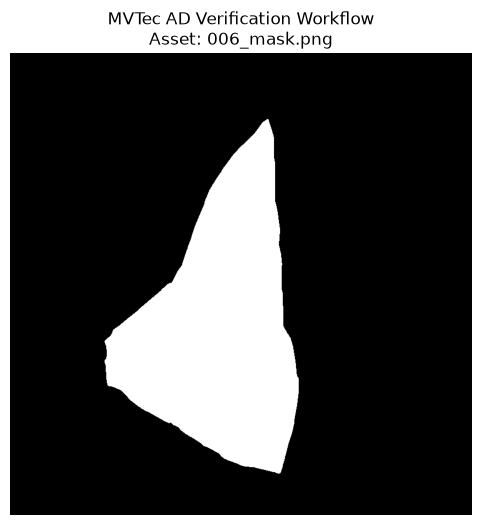

Status: SUCCESS - Image displayed successfully inside workspace window.


In [6]:
print("=== [CELL 6] Launching Matplotlib Rendering Window ===")

if rgb_img is not None:
    plt.figure(figsize=(8, 6))
    plt.imshow(rgb_img)
    plt.title(f"MVTec AD Verification Workflow\nAsset: {os.path.basename(sample_path)}")
    plt.axis("off")
    plt.show()
    print("Status: SUCCESS - Image displayed successfully inside workspace window.")
else:
    print("Status: ABORTED - Unable to draw image due to upstream loading error.")